In [1]:
%load_ext autoreload
%autoreload 2
from neuropy.analyses import correlations 
import numpy as np
import neuropy.analyses.ms_connectivity as msconn
import seaborn as sns
import matplotlib.pyplot as plt
import time
import subjects
skips = {} # epoch='post'
skips[msconn.Key(session='RatU_Day2NSD',epoch="post",excitability='E',conn_type=('pyr','pyr'))]=np.array([41,98])
skips[msconn.Key(session='RatU_Day2NSD',epoch="post",excitability='E',conn_type=('pyr','inter'))]=np.array([44,21])
skips[msconn.Key(session='RatU_Day2NSD',epoch="post",excitability='I',conn_type=('inter','inter'))]=np.array([[129,125],[21,0],[139,66]])

Error importing CuPy
Error importing CuPy


/Users/selinl/miniforge3/envs/NeuroPy2/lib/python3.11/site-packages/xarray/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
sess = subjects.nsd.allsess[5]
use_acceleration = False

In [3]:
cconf=msconn.CCGConfig(use_acceleration=use_acceleration,normalize=msconn.NormalizeBy.REF_FRATE)
ndconf=msconn.NeuronsDatasetConfig(seg_stride=60*60*0.5, seg_len=60*60*5, epochs=['post'], sleep_labels=None,recinfo=sess.recinfo)
nd=msconn.NeuronsDataset(sess,ndconf)

In [4]:
# get maximum number of significant pairs by using the whole dataset
cd=msconn.CCGDataset(nd,cconf)
cd.get_CCG_with_baseline()

EranConv significant pairs
running eranconv (1st pass)
running spike correlations
spike correlation done
eranconv (1st pass) done
=======RatU_Day2NSD=======
Segment(s) are 9.02h each and contain ['9.02'] hours of actual sleep pyr=174 inter=14 
SLEEP0: E/I pairs 173 / 186 | pyr-pyr/E 07 | pyr-inter/E 97 | inter-inter/I 50 | inter-pyr/I 23 | 
SLEEP1: E/I pairs 174 / 174 | pyr-pyr/E 07 | pyr-inter/E 103 | inter-inter/I 48 | inter-pyr/I 22 | 
SLEEP2: E/I pairs 174 / 160 | pyr-pyr/E 07 | pyr-inter/E 105 | inter-inter/I 44 | inter-pyr/I 22 | 
SLEEP3: E/I pairs 178 / 168 | pyr-pyr/E 06 | pyr-inter/E 109 | inter-inter/I 44 | inter-pyr/I 25 | 
SLEEP4: E/I pairs 176 / 182 | pyr-pyr/E 04 | pyr-inter/E 108 | inter-inter/I 44 | inter-pyr/I 32 | 
SLEEP5: E/I pairs 188 / 184 | pyr-pyr/E 04 | pyr-inter/E 116 | inter-inter/I 46 | inter-pyr/I 29 | 
SLEEP6: E/I pairs 196 / 184 | pyr-pyr/E 04 | pyr-inter/E 122 | inter-inter/I 46 | inter-pyr/I 32 | 
SLEEP7: E/I pairs 203 / 180 | pyr-pyr/E 05 | pyr-inter/E 

In [5]:
cd.set_connection_strengths(method="eran_conv")
cd.set_connectivity()

In [6]:
cd.reCCG_connectivity()

running eranconv (2nd pass): sess_RatU_Day2NSD.epoch_post.ex_E.type_pyr-pyr
running spike correlations
spike correlation done
done
running eranconv (2nd pass): sess_RatU_Day2NSD.epoch_post.ex_E.type_pyr-inter
running spike correlations
spike correlation done
done
running eranconv (2nd pass): sess_RatU_Day2NSD.epoch_post.ex_I.type_inter-inter
running spike correlations
spike correlation done
done
running eranconv (2nd pass): sess_RatU_Day2NSD.epoch_post.ex_I.type_inter-pyr
running spike correlations
spike correlation done
done
recomputed CCG for pairs that had been significant in any segment


In [7]:
cd.normalize()
cd.set_connection_strengths()
cd.set_connectivity()

In [8]:
cd.example('connectivity')

sess_RatU_Day2NSD.epoch_post.ex_E.type_pyr-pyr
[ 26 157]      	In segments [0 1 2 3]           	strengths: [109.17698111  88.88888889  53.12346286  26.15840367   2.10390977
   0.           0.           0.           0.        ]
[ 28 157]      	In segments [0 1 2]             	strengths: [52.16375787 41.81236887 28.03582355 16.33903498  3.75167485  0.
  0.          0.          0.        ]
[123  31]      	In segments [0]                 	strengths: [1.21449295e+02 1.62494871e+01 6.19461413e+00 6.69207175e+00
 3.73948270e+00 3.55271368e-15 4.40798335e+00 2.33281493e+00
 1.15696105e+01]
[147   7]      	In segments [0 1 2 3 4 5 6 7]   	strengths: [-54.30070728 -51.32684255 -57.3201997  -61.11973889 -66.41203523
 -66.72194313 -62.22282868 -57.3550824  -65.23687198]
[160  46]      	In segments [0 1 2 3 4 5 6 7 8] 	strengths: [105.61314297 109.5546324  124.23447069 117.28094914 120.6549842
 114.97641509 119.40594059 105.12295082 103.22177041]
[165  46]      	In segments [0 1 2 3 4 5 6 7 8] 	str

In [9]:
skips = {} # epoch='post'
# skips[msconn.Key(session='RatU_Day2NSD',epoch="post",excitability='E',conn_type=('pyr','pyr'))]=np.array([[109, 182]])
# skips[msconn.Key(session='RatU_Day2NSD',epoch="post",excitability='E',conn_type=('pyr','inter'))]=np.array([[3, 129]])
# skips[msconn.Key(session='RatU_Day2NSD',epoch="post",excitability='I',conn_type=('inter','pyr'))]=np.array([[ 21,  59]])


sess_RatU_Day2NSD.epoch_post.ex_E.type_pyr-pyr None


/Users/selinl/Documents/NeuroPy/neuropy/analyses/ms_connectivity.py:1007: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(x_sig, v[x_sig], s=8, c=c,label="_nolegend_")


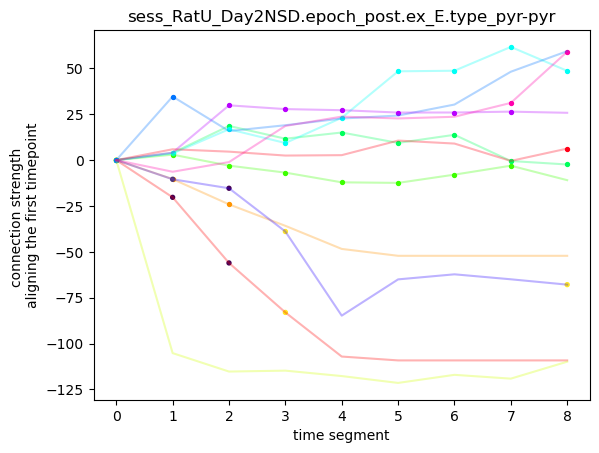

pvals [0.41931777 0.37423681 0.2419962  0.20041145 0.28235677 0.32877586
 0.39344143 0.47839956] threshold 0.00625 

mean values [-0.84228304 -0.9300804  -1.24364032 -1.37081933 -1.13622928 -1.02665513
 -0.89182219 -0.73641179] 

sess_RatU_Day2NSD.epoch_post.ex_E.type_pyr-inter None


/Users/selinl/Documents/NeuroPy/neuropy/analyses/ms_connectivity.py:1007: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(x_sig, v[x_sig], s=8, c=c,label="_nolegend_")


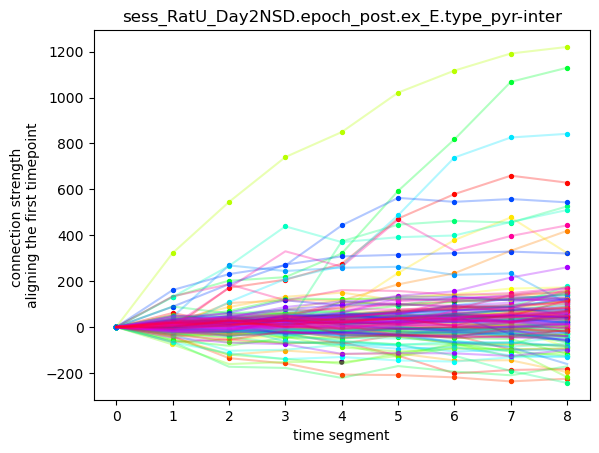

pvals [2.76338090e-02 6.72072426e-03 6.17306519e-04 5.45730404e-04
 9.22851755e-05 4.93773944e-05 5.89616588e-05 5.50036638e-05] threshold 0.00625 

mean values [2.223285   2.74708373 3.49501014 3.53037072 4.01450463 4.17506613
 4.12997456 4.14767891] 

sess_RatU_Day2NSD.epoch_post.ex_I.type_inter-inter None


/Users/selinl/Documents/NeuroPy/neuropy/analyses/ms_connectivity.py:1007: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(x_sig, v[x_sig], s=8, c=c,label="_nolegend_")


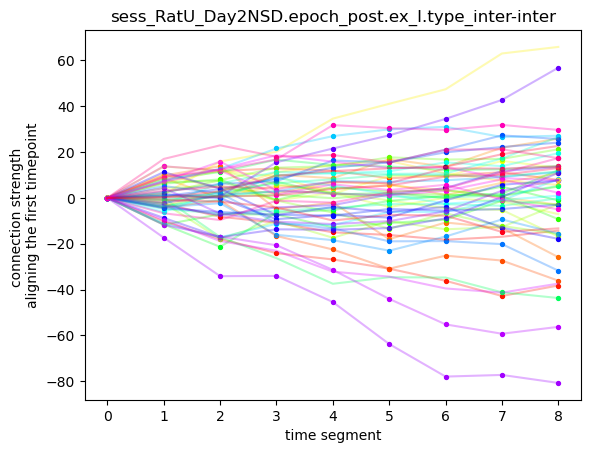

pvals [0.59959389 0.95308898 0.9465823  0.85503777 0.71735416 0.92440848
 0.74649813 0.65906284] threshold 0.00625 

mean values [ 0.52804259  0.05909709 -0.06730586 -0.18355478 -0.36386461 -0.09531826
  0.32488839  0.44361282] 

sess_RatU_Day2NSD.epoch_post.ex_I.type_inter-pyr None


/Users/selinl/Documents/NeuroPy/neuropy/analyses/ms_connectivity.py:1007: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(x_sig, v[x_sig], s=8, c=c,label="_nolegend_")


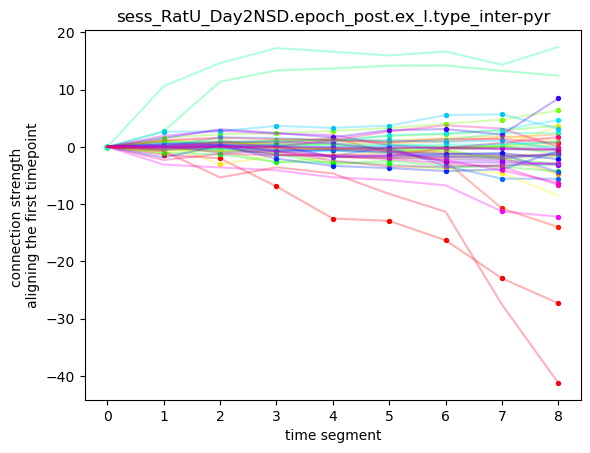

pvals [0.29065213 0.18989956 0.55335709 0.90714258 0.68119928 0.4509924
 0.16256296 0.13463373] threshold 0.00625 

mean values [ 1.06898936  1.33053812  0.59711717 -0.11728784 -0.41344844 -0.76023646
 -1.41926479 -1.52288261] 



In [10]:
cd.plot_connection_strengths(show_legend=False,
                                norm_by_total_strength=False,
                                zero_first_timepoint=True,
                                norm_by_n_sess=False,
                                save=False,
                                root="/home/selinali/Documents/NeuroPy/images/conn_strength_1218_RefRateNorm/1-zero_first_timepoint",
                                skips=skips,
                                debug=False)

# individual plots

In [13]:
_=cd.save_plots(root="~/Documents/NeuroPy/images/ccg_plots_0101_2",conn_types=[('pyr','pyr')])

[Key(session='RatU_Day2NSD', epoch='post', ref_ind=None, target_ind=None, segment=None, excitability='E', conn_type=('pyr', 'pyr'))]
Saving plots under ~/Documents/NeuroPy/images/ccg_plots_0101_2
ccg RatU_Day2NSD ('pyr', 'pyr')
0 [23  9]
1 [ 26 157]
2 [ 28 157]
3 [109 182]
4 [110   9]
5 [120  90]
6 [123  31]
7 [147   7]
8 [160  46]
9 [165  46]
10 [182  10]
done saving plots
done
